In [1]:
# Libraries
import sys
sys.path.append('../')

import numpy as np
import matplotlib.pyplot as plt
import json
from data_processors import *
from scipy.stats import sem, t
import os
import copy
import math
import imageio
import random

## TEST BPO COME REINFORCE SE BH = TRGT

In [2]:
# Funzione per caricare i dati da un percorso
def load_trials(base_path, n_exp):
    trial_performances = []
    for i in range(n_exp):
        trial_path = os.path.join(base_path, f"trial_{i}")
        if os.path.isdir(trial_path):
            try:
                file_path = os.path.join(trial_path, "results.json")
                with open(file_path, 'r') as file:
                    data = json.load(file)
                    trial_performances.append(data["performance"])
            except (FileNotFoundError, json.JSONDecodeError) as e:
                print(f"Errore nel leggere {file_path}: {e}")
    return np.array(trial_performances)  # Converte in array per calcoli successivi

# Funzione per caricare i dati da un percorso
def load_trials_with_var(base_path, n_exp):
    trial_performances = []
    trial_grad_vars = []
    for i in range(n_exp):
        trial_path = os.path.join(base_path, f"trial_{i}")
        if os.path.isdir(trial_path):
            try:
                file_path = os.path.join(trial_path, "results.json")
                with open(file_path, 'r') as file:
                    data = json.load(file)
                    trial_performances.append(data["performance"])
                    trial_grad_vars.append(data["grad_var"])
            except (FileNotFoundError, json.JSONDecodeError) as e:
                print(f"Errore nel leggere {file_path}: {e}")
    return np.array(trial_performances), np.array(trial_grad_vars)  # Converte in array per calcoli successivi

In [23]:
paths = [
    "/home/tedeschi_bpo/learn_RL/results/TEST/reinforce-test_12_03-18_52_PG_200_cartpole_200_099_adam_0001_100_noclip__linear_gaussian_4_std_1_noise_00",
    "/home/tedeschi_bpo/learn_RL/results/TEST/bpo-test_12_03-18_52_PG_200_cartpole_200_099_adam_0001_100_noclip__linear_gaussian_4_std_1_noise_00"
]
# Lista per memorizzare le performance per ogni set
all_performances = []

for path in paths:
    performances = load_trials(path, n_exp=10)
    if performances.size > 0:
        all_performances.append(performances)

lab = ['rf', 'bpo']
print(len(all_performances))

2


33.117374874554706
32.69741756971394


<Figure size 640x480 with 0 Axes>

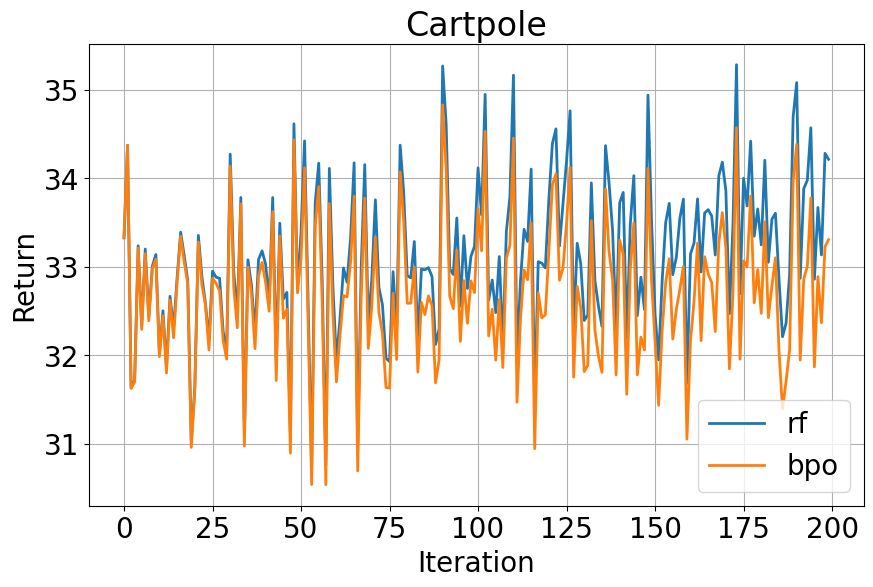

In [24]:
# Plot dei grafici
plt.clf()
# plt.figure(figsize=(6.5, 4.5))
plt.figure(figsize=(10, 6))

for i, performances in enumerate(all_performances):
    if performances.size > 0:
         # Calcola la media e gli intervalli di confidenza
        mean_performance = np.mean(performances, axis=0)
        std_performance = np.std(performances, axis=0)

        # Plot della curva media
        plt.plot(mean_performance, linewidth=2, label = lab[i])

        # Plot dell'intervallo di confidenza
        lower = mean_performance-(std_performance)*1.96/np.sqrt(performances.shape[0])
        higher = mean_performance+(std_performance)*1.96/np.sqrt(performances.shape[0])

        plt.fill_between(
            range(len(mean_performance)),
            lower,
            higher,
            alpha=0.2
        )

        print(np.mean(mean_performance))
        # print(np.mean(lower))
        # print(np.mean(higher))

# Etichette e titolo
plt.title("Cartpole")
plt.xlabel("Iteration")
plt.ylabel("Return")

plt.legend()
plt.grid()
# plt.ylim(bottom=-80)
# plt.xlim(right=80)
# Salva e mostra il grafico
# plt.savefig("dam_1825_b10_g999.pdf", format='pdf')
plt.show()

In [25]:
paths = [
    "/home/tedeschi_bpo/learn_RL/results/TEST/reinforce-test_12_03-19_08_PG_200_cartpole_200_099_adam_0001_100_noclip__linear_gaussian_4_std_1_noise_00",
    "/home/tedeschi_bpo/learn_RL/results/TEST/bpo-test_12_03-19_08_PG_200_cartpole_200_099_adam_0001_100_noclip__linear_gaussian_4_std_1_noise_00"
]
# Lista per memorizzare le performance per ogni set
all_performances = []

for path in paths:
    performances = load_trials(path, n_exp=10)
    if performances.size > 0:
        all_performances.append(performances)

lab = ['rf', 'bpo']
print(len(all_performances))

2


33.117374874554706
33.117374874554706


<Figure size 640x480 with 0 Axes>

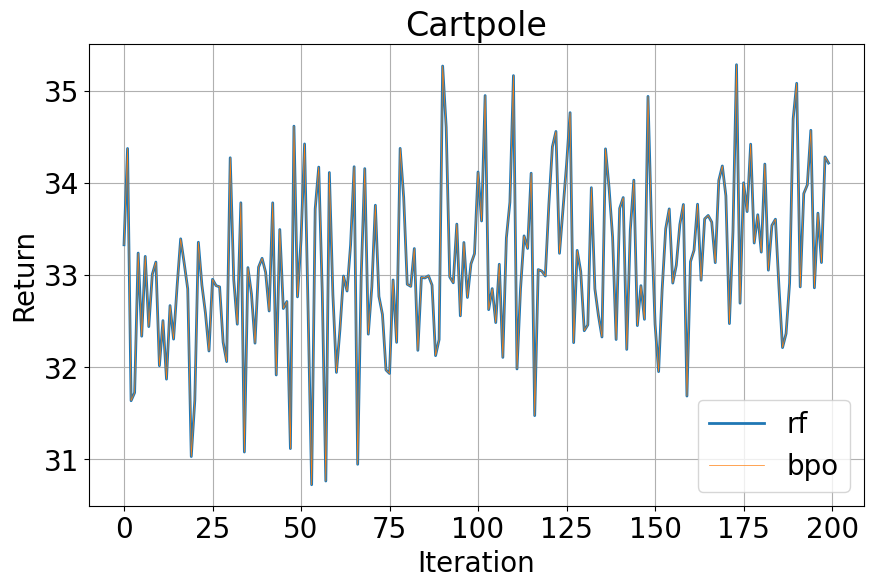

In [26]:
# Plot dei grafici
plt.clf()
# plt.figure(figsize=(6.5, 4.5))
plt.figure(figsize=(10, 6))

for i, performances in enumerate(all_performances):
    if performances.size > 0:
         # Calcola la media e gli intervalli di confidenza
        mean_performance = np.mean(performances, axis=0)
        std_performance = np.std(performances, axis=0)

        # Plot della curva media
        plt.plot(mean_performance, linewidth=2 - 1.5*i, label = lab[i])

        # Plot dell'intervallo di confidenza
        lower = mean_performance-(std_performance)*1.96/np.sqrt(performances.shape[0])
        higher = mean_performance+(std_performance)*1.96/np.sqrt(performances.shape[0])

        plt.fill_between(
            range(len(mean_performance)),
            lower,
            higher,
            alpha=0.2
        )

        print(np.mean(mean_performance))
        # print(np.mean(lower))
        # print(np.mean(higher))

# Etichette e titolo
plt.title("Cartpole")
plt.xlabel("Iteration")
plt.ylabel("Return")

plt.legend()
plt.grid()
# plt.ylim(bottom=-80)
# plt.xlim(right=80)
# Salva e mostra il grafico
# plt.savefig("dam_1825_b10_g999.pdf", format='pdf')
plt.show()

## TEST 2: bpo var and perf

In [35]:
paths = [
    "/home/tedeschi_bpo/learn_RL/results/TEST/COVreinforce-test_12_03-20_19_PG_400_cartpole_200_099_adam_001_100_noclip__linear_gaussian_4_std_1_noise_00",
    "/home/tedeschi_bpo/learn_RL/results/TEST/COVbpo-test_12_03-20_19_PG_400_cartpole_200_099_adam_001_100_noclip__linear_gaussian_4_std_1_noise_00"
]

# Lista per memorizzare le performance per ogni set
all_performances = []
all_vars = []

for path in paths:
    performances, vars = load_trials_with_var(path, n_exp=10)
    if performances.size > 0:
        all_performances.append(performances)
        all_vars.append(vars)

lab = ['rf', 'bpo']
print(len(all_performances))


2


55.53343590840548
55.79135237351947


<Figure size 640x480 with 0 Axes>

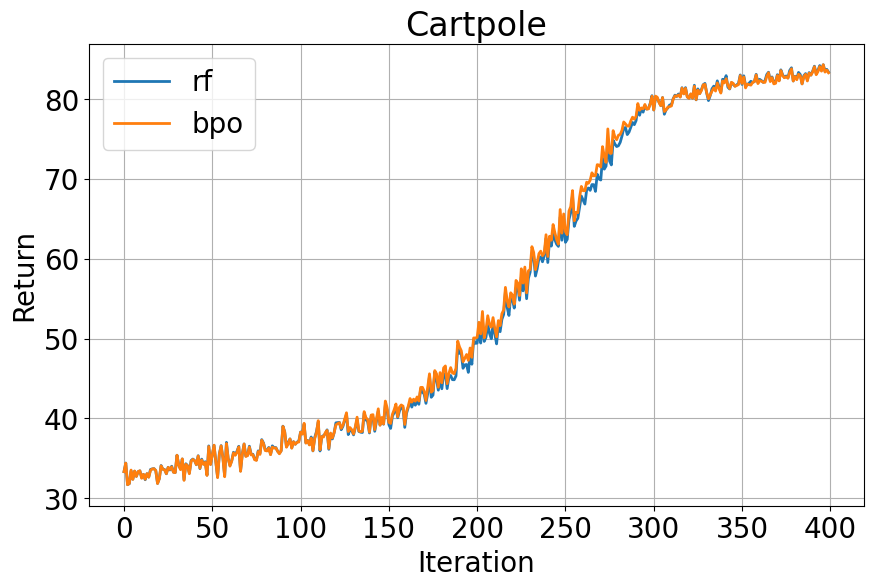

In [36]:
# Plot dei grafici
plt.clf()
# plt.figure(figsize=(6.5, 4.5))
plt.figure(figsize=(10, 6))

for i, performances in enumerate(all_performances):
    if performances.size > 0:
         # Calcola la media e gli intervalli di confidenza
        mean_performance = np.mean(performances, axis=0)
        std_performance = np.std(performances, axis=0)

        # Plot della curva media
        plt.plot(mean_performance, linewidth=2, label = lab[i])

        # Plot dell'intervallo di confidenza
        lower = mean_performance-(std_performance)*1.96/np.sqrt(performances.shape[0])
        higher = mean_performance+(std_performance)*1.96/np.sqrt(performances.shape[0])

        plt.fill_between(
            range(len(mean_performance)),
            lower,
            higher,
            alpha=0.2
        )

        print(np.mean(mean_performance))
        # print(np.mean(lower))
        # print(np.mean(higher))

# Etichette e titolo
plt.title("Cartpole")
plt.xlabel("Iteration")
plt.ylabel("Return")

plt.legend()
plt.grid()
# plt.ylim(bottom=-80)
# plt.xlim(right=80)
# Salva e mostra il grafico
# plt.savefig("dam_1825_b10_g999.pdf", format='pdf')
plt.show()

2059.6260341698962
1724.482677390842


<Figure size 640x480 with 0 Axes>

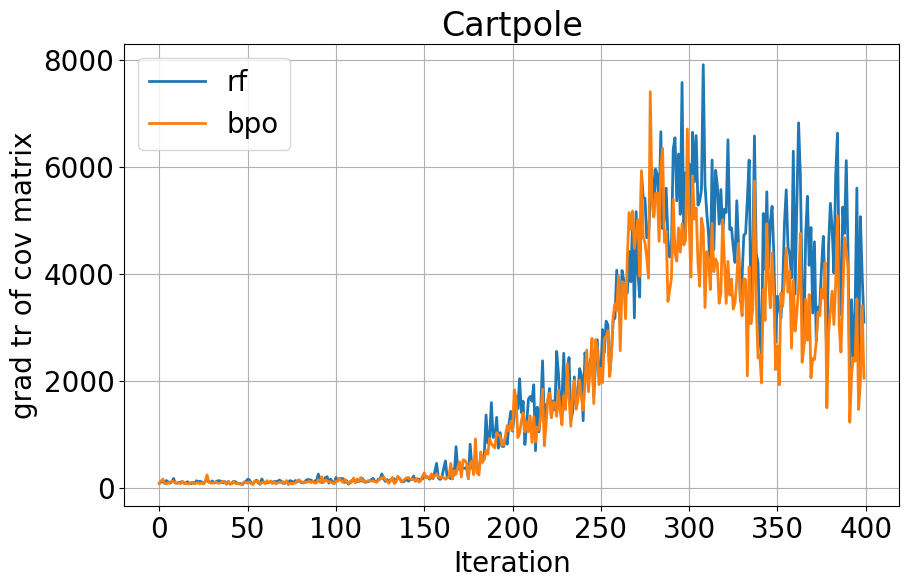

In [37]:
# Plot dei grafici
plt.clf()
# plt.figure(figsize=(6.5, 4.5))
plt.figure(figsize=(10, 6))

for i, vars in enumerate(all_vars):
    if vars.size > 0:
         # Calcola la media e gli intervalli di confidenza
        mean_var = np.mean(vars, axis=0)
        std_var = np.std(vars, axis=0)

        # Plot della curva media
        plt.plot(mean_var, linewidth=2, label = lab[i])

        print(np.mean(mean_var))

# Etichette e titolo
plt.title("Cartpole")
plt.xlabel("Iteration")
plt.ylabel("grad tr of cov matrix")

plt.legend()
plt.grid()
# plt.ylim(bottom=-80)
# plt.xlim(right=80)
# Salva e mostra il grafico
# plt.savefig("dam_1825_b10_g999.pdf", format='pdf')
plt.show()

## TEST 3 BPO and REINF visited states Mountain Car

2


<Figure size 640x480 with 0 Axes>

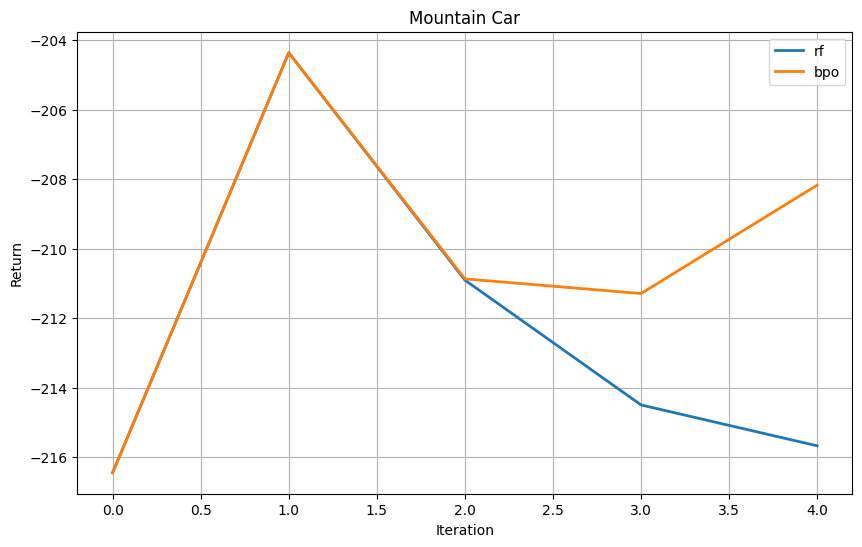

In [3]:
paths = [
    "/home/tedeschi_bpo/learn_RL/results/TEST/STATESreinforce-test_12_04-11_35_PG_5_mountain_car_999_10_adam_0005_100_noclip__deep_gaussian_1184_std_075_noise_00",
    "/home/tedeschi_bpo/learn_RL/results/TEST/STATESbpo-test_12_04-11_36_PG_5_mountain_car_999_10_adam_0005_100_noclip__deep_gaussian_1184_std_075_noise_00"
]
# Lista per memorizzare le performance per ogni set
all_performances = []

for path in paths:
    performances = load_trials(path, n_exp=10)
    if performances.size > 0:
        all_performances.append(performances)

lab = ['rf', 'bpo']
print(len(all_performances))

# Plot dei grafici
plt.clf()
plt.figure(figsize=(10, 6))

for i, performances in enumerate(all_performances):
    if performances.size > 0:
         # Calcola la media e gli intervalli di confidenza
        mean_performance = np.mean(performances, axis=0)
        std_performance = np.std(performances, axis=0)

        # Plot della curva media
        plt.plot(mean_performance, linewidth=2, label = lab[i])


# Etichette e titolo
plt.title("Mountain Car")
plt.xlabel("Iteration")
plt.ylabel("Return")

plt.legend()
plt.grid()
plt.show()

In [4]:
def load_trials_states(base_path, n_exp):
    all_states = []  # will hold arrays of shape (iterations, 5, 100, 2)

    for i in range(n_exp):
        trial_path = os.path.join(base_path, f"trial_{i}")

        if os.path.isdir(trial_path):
            try:
                file_path = os.path.join(trial_path, "results.json")
                with open(file_path, 'r') as file:
                    data = json.load(file)

                    # expect data["states"] to be a nested list structure
                    states = np.array(data["states"])
                    all_states.append(states)

            except (FileNotFoundError, json.JSONDecodeError, KeyError) as e:
                print(f"Errore nel leggere {file_path}: {e}")

    return np.array(all_states)

In [5]:
# Lista per memorizzare gli stati per ogni set
all_states = []

for path in paths:
    states = load_trials_states(path, n_exp=10)
    if states.size > 0:  # check that something was loaded
        all_states.append(states)

# Labels for each set (matching your previous code)
lab = ['rf', 'bpo']

print(len(all_states))  # should match the number of loaded sets


2


In [7]:
import seaborn as sns


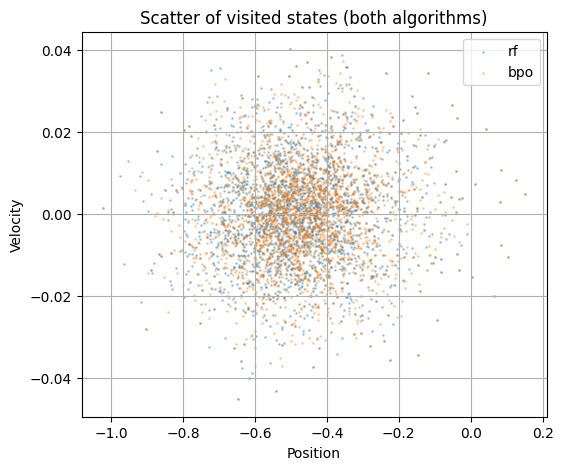

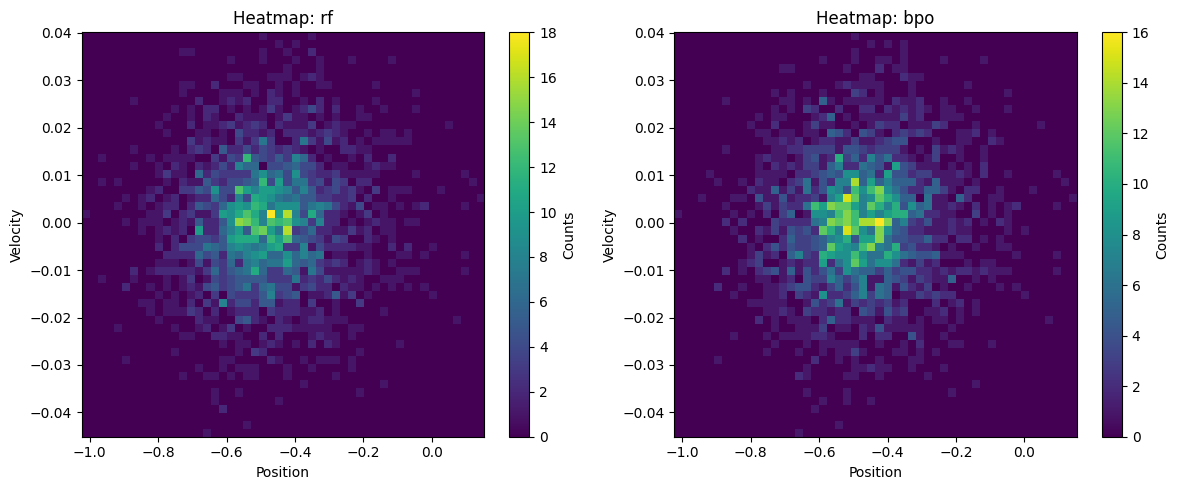

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# --- Scatter plot: both algorithms together ---
plt.figure(figsize=(6,5))

for i, states_alg in enumerate(all_states):
    # Flatten all states: (n_exp * iterations * 5 * 100, 2)
    states_flat = states_alg.reshape(-1, 2)
    
    plt.scatter(states_flat[:,0], states_flat[:,1],
                s=1, alpha=0.3, label=lab[i])

plt.xlabel('Position')
plt.ylabel('Velocity')
plt.title('Scatter of visited states (both algorithms)')
plt.legend()
plt.grid(True)
plt.show()

# --- Heatmaps side by side ---
fig, axes = plt.subplots(1, 2, figsize=(12,5))

for i, states_alg in enumerate(all_states):
    states_flat = states_alg.reshape(-1, 2)
    H, xedges, yedges = np.histogram2d(states_flat[:,0], states_flat[:,1], bins=50)
    
    ax = axes[i]
    im = ax.imshow(H.T, origin='lower', cmap='viridis',
                   extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
                   aspect='auto')
    ax.set_xlabel('Position')
    ax.set_ylabel('Velocity')
    ax.set_title(f'Heatmap: {lab[i]}')
    fig.colorbar(im, ax=ax, label='Counts')

plt.tight_layout()
plt.show()
